## Реализация ансамблевого алгоритма GradientBoosting

In [ ]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay, r2_score
)
from matplotlib import pyplot as plt
from sklearn.base import BaseEstimator

In [28]:
class UniversalGradientBoosting(BaseEstimator):
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=5, mode='regression'):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.mode = mode 
        self.trees = []
        self.base_pred = None

    def logistic_func(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -15, 15)))

    def fit(self, X, y):
        self.trees = []
        if self.mode == 'regression':
            self.base_pred = np.mean(y)
        else:
            prob = np.mean(y)
            self.base_pred = np.log(prob / (1 - prob))

        current_preds = np.full(len(y), self.base_pred)

        for _ in range(self.n_estimators):
            if self.mode == 'regression':
                residuals = y - current_preds
            else:
                probs = self.logistic_func(current_preds)
                residuals = y - probs

            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=81)
            tree.fit(X, residuals)
            
            current_preds += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, x):
        preds = np.full(x.shape[0], self.base_pred)
        
        for tree in self.trees:
            preds += self.learning_rate * tree.predict(x)
        
        if self.mode == 'regression':
            return preds
        else:
            return (self.logistic_func(preds) > 0.5).astype(int)

### Задача регрессии

In [4]:
regression = pd.read_csv("../data/diamonds_filtered.csv")
y_regression = regression['price']
x_regression = regression.drop('price', axis=1)

In [12]:
results_reg = []

def metrics(model, model_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(model, x_regression, y_regression, cv=kf, n_jobs=-1)

    metrics = {
        'Model': model_name,
        'MAE': round(mean_absolute_error(y_regression, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_regression, y_pred)), 4),
        'MAPE': round(mean_absolute_percentage_error(y_regression, y_pred), 4),
        'R2': round(r2_score(y_regression, y_pred), 5),
    }

    results_reg.append(metrics)

In [14]:
model_reg = UniversalGradientBoosting(
    n_estimators=10,  
    learning_rate=0.1,
    max_depth=5,      
    mode='regression' 
)

metrics(model_reg, "Custom Gradient Boosting Regressor")

In [15]:
results_reg_df = pd.DataFrame(results_reg)
results_reg_df

,Model,MAE,RMSE,MAPE,R2
0,Custom Gradient Boosting Regressor,1042.5603,1443.3193,0.6243,0.8382


### Задача классификации

In [17]:
classification = pd.read_csv("../data/credit_card_fraud_filtered.csv")
y_classification = classification['fraud']
x_classification = classification.drop('fraud', axis=1)

In [34]:
results_clf = []

def metrics_clf(model, model_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(model, x_classification, y_classification, cv=kf, n_jobs=-1)

    m = {
        'Model': model_name,
        'Precision': round(precision_score(y_classification, y_pred), 4),
        'Recall': round(recall_score(y_classification, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_classification, y_pred), 4),
        'Accuracy': round(accuracy_score(y_classification, y_pred), 5),
        'F1': round(f1_score(y_classification, y_pred), 4)
    }

    results_clf.append(m)

    print(classification_report(y_classification, y_pred))

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ConfusionMatrixDisplay.from_predictions(y_classification, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title("Confusion Matrix")
    
    RocCurveDisplay.from_predictions(y_classification, y_pred, ax=ax[1])
    ax[1].set_title("ROC Curve")
    plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794



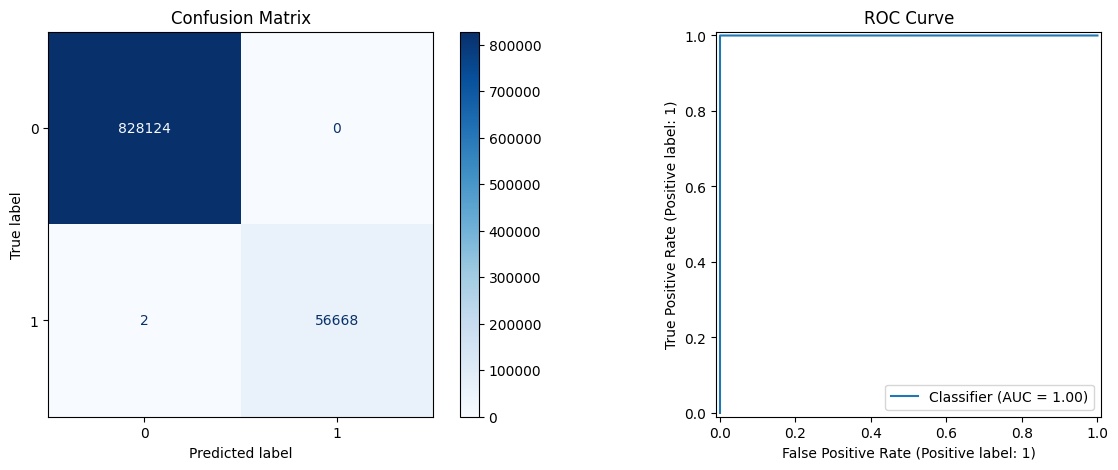

In [35]:
model_clf = UniversalGradientBoosting(
    n_estimators=40,  
    learning_rate=0.1,
    max_depth=5,      
    mode='classification' 
)

metrics_clf(model_clf, "Custom Gradient Boosting Classificator")

In [36]:
results_clf_df = pd.DataFrame(results_clf)
results_clf_df

,Model,Precision,Recall,ROC-AUC,Accuracy,F1
0,Custom Gradient Boosting Classificator,1.0,1.0,1.0,1.0,1.0
